In [1]:
import torch
import torch.nn as nn
from transformers import PreTrainedModel, PretrainedConfig, AutoTokenizer
from transformers import Trainer, TrainingArguments
import pickle
from datasets import Dataset


#

/media/zvi/E69CDDBA9CDD8589/Aregawi/offroad/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# ============================= #
#  1. CREATE CUSTOM GPT2 CONFIG  #
# ============================= #

class TLMConfig(PretrainedConfig):
    model_type = "TLM"
    
    def __init__(self, vocab_size=1600, hidden_size=256, num_hidden_layers=4,
                 num_attention_heads=8, intermediate_size=1024, **kwargs):
        super().__init__(**kwargs)
        self.vocab_size = vocab_size
        
        # STANDARD HUGGINGFACE NAMES
        self.hidden_size = hidden_size
        self.num_hidden_layers = num_hidden_layers
        self.num_attention_heads = num_attention_heads
        self.intermediate_size = intermediate_size
        
        # GPT2-SPECIFIC NAMES (aliases)
        self.n_embd = hidden_size
        self.n_layer = num_hidden_layers
        self.n_head = num_attention_heads
        self.n_inner = intermediate_size
        
        # POSITIONAL & DROPOUT
        self.max_position_embeddings = 256  # 
        self.embd_pdrop = 0.1
        self.attn_pdrop = 0.1
        self.resid_pdrop = 0.1
        
        # ATTENTION SCALING
        self.scale_attn_weights = True
        self.scale_attn_by_inverse_layer_idx = True
        self.reorder_and_upcast_attn = False
        
        # ACTIVATION & NORMALIZATION
        self.activation_function = "gelu"
        self.layer_norm_epsilon = 1e-5
        
        # INITIALIZATION
        self.initializer_range = 0.02
        
        # OTHER REQUIRED ATTRIBUTES
        self.num_labels = 1
        self.summary_type = "cls_index"
        self.summary_use_pred_layer = False
        self.add_cross_attention = False
        self.tie_word_embeddings = True
        self.use_cache = True  # 

In [3]:
# ============================= #
#  2. BUILD MINIMAL TRANSFORMER  #
# ============================= #

from transformers import GPT2LMHeadModel

class TLM(GPT2LMHeadModel):
    config_class = TLMConfig
    
    def __init__(self, config):
        super().__init__(config)

In [4]:
# ============================= #
#  TERRAIN TOKENIZER (NO OBSTACLES)
# ============================= #

from transformers import PreTrainedTokenizerFast
from tokenizers import Tokenizer as TokenizerLib
from tokenizers.models import WordLevel
from tokenizers.pre_tokenizers import WhitespaceSplit

# ---------- STEP 1: BUILD VOCAB ----------
custom_tokens = []

# Coordinate tokens (40x40 grid)
for y in range(40):
    for x in range(40):
        custom_tokens.append(f"{y},{x}")

# Structure tokens
custom_tokens.extend([
    "start:", "goal:", "path:", "terrain:",
    
])

# Create vocab dictionary
vocab = {token: idx for idx, token in enumerate(custom_tokens)}

# Add special tokens safely
vocab["<pad>"] = len(vocab)
vocab["<eos>"] = len(vocab)
vocab["<unk>"] = len(vocab)

print(f"✓ Custom tokenizer vocab size: {len(vocab)}")

# ---------- STEP 2: BUILD TOKENIZER ----------
tokenizer_lib = TokenizerLib(
    WordLevel(vocab=vocab, unk_token="<unk>")
)

tokenizer_lib.pre_tokenizer = WhitespaceSplit()

# Wrap with HuggingFace tokenizer
tokenizer = PreTrainedTokenizerFast(
    tokenizer_object=tokenizer_lib,
    unk_token="<unk>",
    pad_token="<pad>",
    eos_token="<eos>"
)

print(f" Final tokenizer vocab size: {len(tokenizer)}")
print(f" PAD token ID: {tokenizer.pad_token_id}")
print(f" EOS token ID: {tokenizer.eos_token_id}")
print(f" UNK token ID: {tokenizer.unk_token_id}")

# ---------- STEP 3: TEST TOKENIZER ----------
example_text = (
    "start: 0,0 "
    "goal: 10,10 "
    "path: 0,0 1,1 2,2 3,3 4,4 "
    
)

encoded = tokenizer.encode(example_text)

print("\n=== Example Tokenization ===")
print("Text:")
print(example_text)

print("\nToken IDs:")
print(encoded)

print("\nDecoded back:")
print(tokenizer.decode(encoded))

# ---------- STEP 4: OPTIONAL SAVE ----------
# Save tokenizer for reuse
tokenizer.save_pretrained("terrain_tokenizer")

print("\n✓ Tokenizer saved to ./terrain_tokenizer")

✓ Custom tokenizer vocab size: 1607
 Final tokenizer vocab size: 1607
 PAD token ID: 1604
 EOS token ID: 1605
 UNK token ID: 1606

=== Example Tokenization ===
Text:
start: 0,0 goal: 10,10 path: 0,0 1,1 2,2 3,3 4,4 

Token IDs:
[1600, 0, 1601, 410, 1602, 0, 41, 82, 123, 164]

Decoded back:
start: 0,0 goal: 10,10 path: 0,0 1,1 2,2 3,3 4,4

✓ Tokenizer saved to ./terrain_tokenizer


In [5]:
# ============================= #
#  4. INITIALIZE TINY MODEL     #
# ============================= #

config = TLMConfig(
    vocab_size=len(tokenizer),
    hidden_size=256,
    num_hidden_layers=4,
    num_attention_heads=8,
    intermediate_size=1024,
)
import os

#  Load pre-trained weights (retains previous learning)
try:
    model = TLM.from_pretrained("./offroad-path-40x40-scratch", config=config)
    print("✓ Loaded pre-trained model with previous learning")
except:
    model = TLM(config)
    print("✓ Initialized fresh model")


#model = TLM(config)
#print("✓ Initialized fresh model")

#rint(f"✓ Model parameters: {sum(p.numel() for p in model.parameters()):,}")

Loading weights: 100%|██████████| 52/52 [00:00<00:00, 27962.03it/s]

✓ Loaded pre-trained model with previous learning


In [6]:
# ============================= #
#  5. LOAD & PREPARE DATA       #
# ============================= #

import pickle
import pandas as pd
from datasets import Dataset

# Load DataFrame from pickle file
print("Loading paths DataFrame from pickle...")
paths_df = pd.read_pickle("offroad_paths_mars_40.pkl")
print(f" Loaded DataFrame with shape: {paths_df.shape}")
print(f" Columns: {list(paths_df.columns)}")
print(f" Number of unique paths: {len(paths_df['path_id'].unique())}")

def dataframe_to_path_strings(df, end_token="<END>"):
    """Convert DataFrame to path strings format and append <END> token"""
    path_strings = []
    
    # Group by path_id to get individual paths
    for path_id, group in df.groupby('path_id'):
        # Sort by the original order (assuming rows are in path order)
        group = group.sort_index()
        
        # Extract coordinates
        path_coords = list(zip(group['i'], group['j']))
        
        if len(path_coords) < 2:  # Skip single-point paths
            continue
            
        # Start & goal
        start = f"{int(path_coords[0][0])},{int(path_coords[0][1])}"
        goal = f"{int(path_coords[-1][0])},{int(path_coords[-1][1])}"

        # Path sequence
        path_str = " ".join([f"{int(i)},{int(j)}" for i, j in path_coords])

        # Final format with end-of-path token
        path_strings.append(f"start: {start} goal: {goal} path: {path_str} {end_token}")
    
    return path_strings

# Convert DataFrame to string format with <END> token
print("Converting DataFrame to path strings with <END> token...")
string_paths = dataframe_to_path_strings(paths_df, end_token="<END>")

# Create dataset
dataset = Dataset.from_dict({"text": string_paths})

# Train/test split
split_dataset = dataset.train_test_split(
    test_size=0.1,
    shuffle=True,
    seed=42
)

print(f"✓ Dataset size: {len(string_paths)}")
print(f"✓ Example path:\n{string_paths[0]}")

Loading paths DataFrame from pickle...
 Loaded DataFrame with shape: (9838291, 6)
 Columns: ['path_id', 'i', 'j', 'x', 'y', 'z']
 Number of unique paths: 500000
Converting DataFrame to path strings with <END> token...
✓ Dataset size: 499672
✓ Example path:
start: 22,30 goal: 11,12 path: 22,30 22,29 22,28 22,27 22,26 21,25 20,24 19,23 18,22 18,21 17,20 17,19 17,18 16,17 15,16 14,15 13,14 12,13 11,12 <END>


In [7]:
# ============================= #
#  6. TOKENIZATION + MASKING    #
# ============================= #

def tokenize(example):
    tokens = tokenizer(example["text"], truncation=True, padding="max_length", max_length=256)
    labels = list(tokens["input_ids"])
    
    # Simple masking: Only mask the "path:" keyword, not the path coordinates
    # This teaches model: "path: is a label, predict the actual coordinates"
    try:
        path_token_id = tokenizer.convert_tokens_to_ids("path:")
        path_idx = labels.index(path_token_id)
        
        #  ONLY mask "path:" keyword itself (not the coordinates that follow)
        labels[path_idx] = -100
    except ValueError:
        pass  # No "path:" token found in this example
    
    tokens["labels"] = labels
    return tokens

tokenized_splits = split_dataset.map(tokenize, batched=False)

Map: 100%|██████████| 49968/49968 [00:10<00:00, 4785.22 examples/s]


In [8]:
# ============================= #
#  7. CUSTOM TRAINER WITH       #
#     DISTANCE PENALTY (NO JUMPS)#
# ============================= #

# ============================= #
#  STANDARD TRAINING #
# ============================= #

training_args = TrainingArguments(
    output_dir="./offroad-path-40x40-scratch_mars",
    per_device_train_batch_size=32,
    per_device_eval_batch_size=32,
    num_train_epochs=5,
    eval_strategy="epoch",
    logging_steps=50,
    save_strategy="epoch",
    fp16=True,
    learning_rate=5e-4,
    warmup_steps=500,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=tokenized_splits["train"],
    eval_dataset=tokenized_splits["test"],
    processing_class=tokenizer,
)

# Train with standard cross-entropy loss
print("Starting training (standard, no jump penalty)...")
trainer.train(resume_from_checkpoint=None)

# SAVE FINAL MODEL
model.save_pretrained("./offroad-path-40x40-scratch_mars")
tokenizer.save_pretrained("./offroad-path-40x40-scratch_mars")

print("Model trained with standard loss and saved!")
print("Training complete!")


/media/zvi/E69CDDBA9CDD8589/Aregawi/offroad/.venv/lib/python3.10/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at ../c10/cuda/CUDAFunctions.cpp:108.)
  return torch._C._cuda_getDeviceCount() > 0
The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'eos_token_id': 1605, 'pad_token_id': 1604}.


Starting training (standard, no jump penalty)...


`loss_type=None` was set in the config but it is unrecognized. Using the default loss: `ForCausalLMLoss`.


Epoch,Training Loss,Validation Loss
1,0.063133,0.061401
2,0.061221,0.059793
3,0.060127,0.059058
4,0.059370,0.058605
5,0.058818,0.058346


Writing model shards: 100%|██████████| 1/1 [00:00<00:00, 16.98it/s]

Model trained with standard loss and saved!
Training complete!


You are using a model of type `TLM` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.
Loading weights: 100%|██████████| 52/52 [00:00<00:00, 8614.92it/s]


✓ Model loaded
✓ Tokenizer size: 1607

Prompt: start: 35,8 goal: 5,20 path:

Generated:
 start: 35,8 goal: 5,20 path: 35,8 34,8 33,8 32,8 31,8 30,8 29,8 28,8 27,8 26,8 25,8 24,8 23,9 22,10 21,11 20,11 19,11 18,12 17,13 16,14 15,15 14,16 13,16 12,16 11,17 10,17 9,18 8,18 7,18 6,19 5,20

Extracted path (31 points):
[(35, 8), (34, 8), (33, 8), (32, 8), (31, 8), (30, 8), (29, 8), (28, 8), (27, 8), (26, 8), (25, 8), (24, 8), (23, 9), (22, 10), (21, 11), (20, 11), (19, 11), (18, 12), (17, 13), (16, 14), (15, 15), (14, 16), (13, 16), (12, 16), (11, 17), (10, 17), (9, 18), (8, 18), (7, 18), (6, 19), (5, 20)]
Path plotted


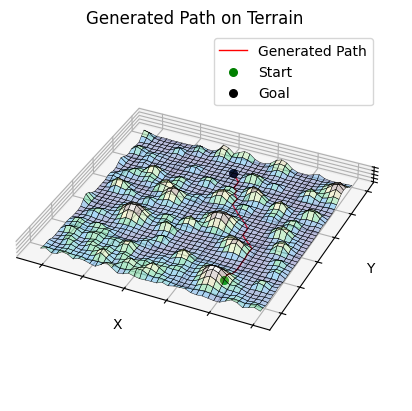

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from transformers import AutoTokenizer
import torch
import torch.nn.functional as F

# If these are in your project, keep them as-is
# from your_module import TLM, TLMConfig

# ============================= #
#  LOAD MODEL & TOKENIZER       #
# ============================= #

tokenizer = AutoTokenizer.from_pretrained("offroad-path-40x40-scratch_mars")

config = TLMConfig.from_pretrained("offroad-path-40x40-scratch_mars")
model = TLM.from_pretrained("offroad-path-40x40-scratch_mars", config=config)

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

print("✓ Model loaded")
print(f"✓ Tokenizer size: {len(tokenizer)}")

# ============================= #
#  LOAD TERRAIN (map.out)       #
# ============================= #

df = pd.read_csv("map_mars_40.out", sep=",", header=None)
df = df.apply(lambda col: pd.to_numeric(col, errors="coerce"))
df.columns = ["i", "j", "x", "y", "z"]
df = df.dropna()

X = df.pivot(index="i", columns="j", values="x").values
Y = df.pivot(index="i", columns="j", values="y").values
Z = df.pivot(index="i", columns="j", values="z").values

# ============================= #
#  GENERATION HELPERS           #
# ============================= #

def top_p_filtering(logits, top_p=0.95):
    """
    Nucleus (top-p) filtering on 1D logits tensor.
    """
    sorted_logits, sorted_indices = torch.sort(logits, descending=True)
    sorted_probs = F.softmax(sorted_logits, dim=-1)
    cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

    # Remove tokens with cumulative probability above top_p
    sorted_indices_to_remove = cumulative_probs > top_p
    # Keep at least one token
    sorted_indices_to_remove[0] = False

    indices_to_remove = sorted_indices[sorted_indices_to_remove]
    logits[indices_to_remove] = -float("inf")
    return logits

def path_reached_goal(decoded_text, goal_coord):
    """
    Stop generation only when the path portion ends exactly with the goal coordinate.
    """
    goal_str = f"{goal_coord[0]},{goal_coord[1]}"

    if "path:" not in decoded_text:
        return False

    path_part = decoded_text.split("path:", 1)[1].strip()
    if not path_part:
        return False

    tokens = path_part.split()
    return len(tokens) > 0 and tokens[-1] == goal_str

@torch.no_grad()
def generate_until_goal(
    model,
    tokenizer,
    input_text,
    goal_coord,
    max_new_tokens=128,
    temperature=0.6,
    top_p=0.95,
    do_sample=True,
):
    """
    Generate token-by-token and stop immediately once the last generated coordinate
    in the path equals the goal coordinate.
    """
    inputs = tokenizer(input_text, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"]
    attention_mask = inputs["attention_mask"]

    generated_ids = input_ids.clone()

    for _ in range(max_new_tokens):
        outputs = model(input_ids=generated_ids, attention_mask=torch.ones_like(generated_ids))
        next_token_logits = outputs.logits[:, -1, :].squeeze(0)

        if temperature is not None and temperature > 0:
            next_token_logits = next_token_logits / temperature

        if do_sample:
            filtered_logits = top_p_filtering(next_token_logits.clone(), top_p=top_p)
            probs = F.softmax(filtered_logits, dim=-1)
            next_token_id = torch.multinomial(probs, num_samples=1)
        else:
            next_token_id = torch.argmax(next_token_logits, dim=-1, keepdim=True)

        generated_ids = torch.cat([generated_ids, next_token_id.unsqueeze(0)], dim=1)

        decoded_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

        # Stop exactly when the generated path reaches the goal coordinate
        if path_reached_goal(decoded_text, goal_coord):
            break

        # Optional fallback: stop on eos if model emits it
        if tokenizer.eos_token_id is not None and next_token_id.item() == tokenizer.eos_token_id:
            break

    return tokenizer.decode(generated_ids[0], skip_special_tokens=True)

# ============================= #
#  GENERATE PATH                #
# ============================= #

start_coord = (35, 8)
goal_coord = (5, 20)

input_text = f"start: {start_coord[0]},{start_coord[1]} goal: {goal_coord[0]},{goal_coord[1]} path:"
print("\nPrompt:", input_text)

generated_text = generate_until_goal(
    model=model,
    tokenizer=tokenizer,
    input_text=input_text,
    goal_coord=goal_coord,
    max_new_tokens=128,
    temperature=0.6,
    top_p=0.95,
    do_sample=True,
)

print("\nGenerated:\n", generated_text)

# ============================= #
#  EXTRACT PATH                 #
# ============================= #

def extract_path(text):
    try:
        path_part = text.split("path:", 1)[1]
        tokens = path_part.strip().split()

        coords = []
        for token in tokens:
            if "," not in token:
                break

            parts = token.split(",")
            if len(parts) != 2:
                break

            try:
                y, x = int(parts[0]), int(parts[1])
            except ValueError:
                break

            if 0 <= y < 40 and 0 <= x < 40:
                coords.append((y, x))
            else:
                break

        return coords
    except Exception:
        return []

path = extract_path(generated_text)

print(f"\nExtracted path ({len(path)} points):")
print(path)

# ============================= #
#  MAP PATH → TERRAIN (X,Y,Z)   #
# ============================= #

path_x, path_y, path_z = None, None, None

if path is not None and len(path) > 0:
    path = np.array(path)

    path_x = X[path[:, 0], path[:, 1]]
    path_y = Y[path[:, 0], path[:, 1]]
    path_z = Z[path[:, 0], path[:, 1]]

# ============================= #
#  PLOT 3D TERRAIN + PATH       #
# ============================= #

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X, Y, Z,
    cmap="terrain",
    edgecolor="black",
    linewidth=0.3,
    alpha=0.3
)

if path is not None and len(path) > 0:
   
    ax.plot(
        path_x, path_y, path_z,
        color="red",
        linewidth=1,
        label="Generated Path"
    )

    ax.scatter(
        path_x[0], path_y[0], path_z[0],
        color="green", s=30, label="Start"
    )

    ax.scatter(
        path_x[-1], path_y[-1], path_z[-1],
        color="black", s=30, label="Goal"
    )

    print("Path plotted")
else:
    print("No valid path generated")

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

# Remove Z-axis numbering
ax.set_zticklabels([])
ax.set_xticklabels([])
ax.set_yticklabels([])
#ax.set_zticks([])
x_range = X.max() - X.min()
y_range = Y.max() - Y.min()
z_range = Z.max() - Z.min()
ax.set_box_aspect([x_range, y_range, z_range])

ax.view_init(elev=35, azim=115)
ax.set_title("Generated Path on Terrain")
ax.legend()

plt.show()

You are using a model of type `TLM` to instantiate a model of type ``. This may be expected if you are loading a checkpoint that shares a subset of the architecture (e.g., loading a `sam2_video` checkpoint into `Sam2Model`), but is otherwise not supported and can yield errors. Please verify that the checkpoint is compatible with the model you are instantiating.
Loading weights: 100%|██████████| 52/52 [00:00<00:00, 10818.64it/s]


✓ Model loaded
✓ Tokenizer size: 1607

Prompt: start: 35,8 goal: 5,22 path:

Generated:
 start: 35,8 goal: 5,22 path: 35,8 34,8 33,8 32,9 31,10 30,11 29,12 28,12 27,13 26,13 25,14 24,15 23,16 22,17 21,18 20,19 19,20 18,20 17,21 16,21 15,21 14,21 13,21 12,21 11,21 10,21 9,21 8,22 7,22 6,22 5,22

Extracted model path (31 points):
[(35, 8), (34, 8), (33, 8), (32, 9), (31, 10), (30, 11), (29, 12), (28, 12), (27, 13), (26, 13), (25, 14), (24, 15), (23, 16), (22, 17), (21, 18), (20, 19), (19, 20), (18, 20), (17, 21), (16, 21), (15, 21), (14, 21), (13, 21), (12, 21), (11, 21), (10, 21), (9, 21), (8, 22), (7, 22), (6, 22), (5, 22)]

Dijkstra path (31 points):
[(35, 8), (34, 8), (33, 8), (32, 8), (31, 8), (30, 9), (29, 9), (28, 9), (27, 9), (26, 9), (25, 9), (24, 9), (23, 9), (22, 9), (21, 9), (20, 9), (19, 9), (18, 9), (17, 10), (16, 11), (15, 12), (14, 13), (13, 14), (12, 15), (11, 16), (10, 17), (9, 18), (8, 19), (7, 20), (6, 21), (5, 22)]


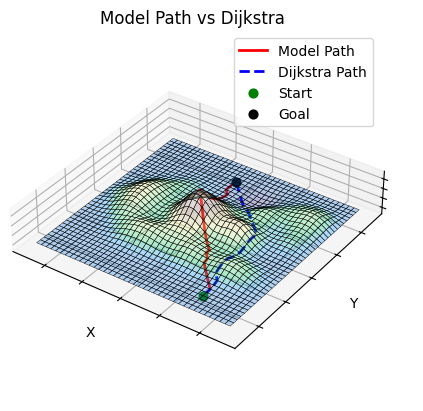

In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F
import heapq
from transformers import AutoTokenizer

# If these are in your project, keep them
# from your_module import TLM, TLMConfig

# ============================= #
#  LOAD MODEL & TOKENIZER       #
# ============================= #

tokenizer = AutoTokenizer.from_pretrained("offroad-path-40x40-scratch_mars")

config = TLMConfig.from_pretrained("offroad-path-40x40-scratch_mars")
model = TLM.from_pretrained("offroad-path-40x40-scratch_mars", config=config)

model.eval()
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

if tokenizer.pad_token_id is None:
    tokenizer.pad_token = tokenizer.eos_token

print("✓ Model loaded")
print(f"✓ Tokenizer size: {len(tokenizer)}")

# ============================= #
#  LOAD TERRAIN                 #
# ============================= #

df = pd.read_csv("map.out", sep=",", header=None)
df = df.apply(lambda col: pd.to_numeric(col, errors="coerce"))
df.columns = ["i", "j", "x", "y", "z"]
df = df.dropna()

X = df.pivot(index="i", columns="j", values="x").values
Y = df.pivot(index="i", columns="j", values="y").values
Z = df.pivot(index="i", columns="j", values="z").values

rows, cols = Z.shape

# ============================= #
#  DIJKSTRA (OFF-ROAD)          #
# ============================= #

# 8-connected grid
neighbors = [(-1,0),(1,0),(0,-1),(0,1),
             (-1,-1),(-1,1),(1,-1),(1,1)]

def cost(r1, c1, r2, c2):
    dx = X[r2, c2] - X[r1, c1]
    dy = Y[r2, c2] - Y[r1, c1]
    dz = Z[r2, c2] - Z[r1, c1]
    return np.sqrt(dx*dx + dy*dy + dz*dz)

def dijkstra(start, goal):
    dist = np.full(Z.shape, np.inf)
    prev = np.empty(Z.shape, dtype=object)

    dist[start] = 0
    pq = [(0, start)]

    while pq:
        d, (r, c) = heapq.heappop(pq)

        if (r, c) == goal:
            break

        # Skip stale heap entries
        if d > dist[r, c]:
            continue

        for dr, dc in neighbors:
            nr, nc = r + dr, c + dc

            if 0 <= nr < rows and 0 <= nc < cols:
                new_d = d + cost(r, c, nr, nc)

                if new_d < dist[nr, nc]:
                    dist[nr, nc] = new_d
                    prev[nr, nc] = (r, c)
                    heapq.heappush(pq, (new_d, (nr, nc)))

    # reconstruct path
    if np.isinf(dist[goal]):
        return []

    path = []
    cur = goal
    while cur is not None:
        path.append(cur)
        cur = prev[cur]
    path.reverse()

    return path

# ============================= #
#  GENERATION HELPERS           #
# ============================= #

def top_p_filtering(logits, top_p=0.95):
    sorted_logits, sorted_indices = torch.sort(logits, descending=True)
    sorted_probs = F.softmax(sorted_logits, dim=-1)
    cumulative_probs = torch.cumsum(sorted_probs, dim=-1)

    sorted_indices_to_remove = cumulative_probs > top_p
    sorted_indices_to_remove[0] = False

    indices_to_remove = sorted_indices[sorted_indices_to_remove]
    logits[indices_to_remove] = -float("inf")
    return logits

def path_reached_goal(decoded_text, goal_coord):
    goal_str = f"{goal_coord[0]},{goal_coord[1]}"

    if "path:" not in decoded_text:
        return False

    path_part = decoded_text.split("path:", 1)[1].strip()
    if not path_part:
        return False

    tokens = path_part.split()
    return len(tokens) > 0 and tokens[-1] == goal_str

@torch.no_grad()
def generate_until_goal(
    model,
    tokenizer,
    input_text,
    goal_coord,
    max_new_tokens=128,
    temperature=0.6,
    top_p=0.95,
    do_sample=True,
):
    inputs = tokenizer(input_text, return_tensors="pt").to(device)
    input_ids = inputs["input_ids"]

    generated_ids = input_ids.clone()

    for _ in range(max_new_tokens):
        outputs = model(
            input_ids=generated_ids,
            attention_mask=torch.ones_like(generated_ids)
        )
        next_token_logits = outputs.logits[:, -1, :].squeeze(0)

        if temperature is not None and temperature > 0:
            next_token_logits = next_token_logits / temperature

        if do_sample:
            filtered_logits = top_p_filtering(next_token_logits.clone(), top_p=top_p)
            probs = F.softmax(filtered_logits, dim=-1)
            next_token_id = torch.multinomial(probs, num_samples=1)
        else:
            next_token_id = torch.argmax(next_token_logits, dim=-1, keepdim=True)

        generated_ids = torch.cat([generated_ids, next_token_id.unsqueeze(0)], dim=1)

        decoded_text = tokenizer.decode(generated_ids[0], skip_special_tokens=True)

        if path_reached_goal(decoded_text, goal_coord):
            break

        if tokenizer.eos_token_id is not None and next_token_id.item() == tokenizer.eos_token_id:
            break

    return tokenizer.decode(generated_ids[0], skip_special_tokens=True)

# ============================= #
#  GENERATE MODEL PATH          #
# ============================= #

start_coord = (35, 8)
goal_coord = (5, 22)

input_text = f"start: {start_coord[0]},{start_coord[1]} goal: {goal_coord[0]},{goal_coord[1]} path:"
print("\nPrompt:", input_text)

generated_text = generate_until_goal(
    model=model,
    tokenizer=tokenizer,
    input_text=input_text,
    goal_coord=goal_coord,
    max_new_tokens=128,
    temperature=0.6,
    top_p=0.95,
    do_sample=True,
)

print("\nGenerated:\n", generated_text)

# ============================= #
#  EXTRACT MODEL PATH           #
# ============================= #

def extract_path(text):
    try:
        path_part = text.split("path:", 1)[1]
        tokens = path_part.strip().split()

        coords = []
        for token in tokens:
            if "," not in token:
                break

            parts = token.split(",")
            if len(parts) != 2:
                break

            try:
                y, x = int(parts[0]), int(parts[1])
            except ValueError:
                break

            if 0 <= y < rows and 0 <= x < cols:
                coords.append((y, x))
            else:
                break

        return coords
    except Exception:
        return []

model_path = extract_path(generated_text)

print(f"\nExtracted model path ({len(model_path)} points):")
print(model_path)

# ============================= #
#  DIJKSTRA PATH                #
# ============================= #

dijkstra_path = dijkstra(start_coord, goal_coord)

print(f"\nDijkstra path ({len(dijkstra_path)} points):")
print(dijkstra_path)

# ============================= #
#  MAP PATHS TO TERRAIN         #
# ============================= #

model_x = model_y = model_z = None
dijk_x = dijk_y = dijk_z = None

if model_path and len(model_path) > 0:
    model_path_np = np.array(model_path)
    model_x = X[model_path_np[:, 0], model_path_np[:, 1]]
    model_y = Y[model_path_np[:, 0], model_path_np[:, 1]]
    model_z = Z[model_path_np[:, 0], model_path_np[:, 1]]

if dijkstra_path and len(dijkstra_path) > 0:
    dijkstra_path_np = np.array(dijkstra_path)
    dijk_x = X[dijkstra_path_np[:, 0], dijkstra_path_np[:, 1]]
    dijk_y = Y[dijkstra_path_np[:, 0], dijkstra_path_np[:, 1]]
    dijk_z = Z[dijkstra_path_np[:, 0], dijkstra_path_np[:, 1]]

# ============================= #
#  PLOT TERRAIN + BOTH PATHS    #
# ============================= #

fig = plt.figure()
ax = fig.add_subplot(111, projection="3d")

ax.plot_surface(
    X, Y, Z,
    cmap="terrain",
    edgecolor="black",
    linewidth=0.3,
    alpha=0.3
)

if model_x is not None:
    ax.plot(
        model_x, model_y, model_z,
        color="red",
        linewidth=2,
        label="Model Path"
    )

if dijk_x is not None:
    ax.plot(
        dijk_x, dijk_y, dijk_z,
        color="blue",
        linestyle="--",
        linewidth=2,
        label="Dijkstra Path"
    )

# Shared start/goal
sr, sc = start_coord
gr, gc = goal_coord

ax.scatter(
    X[sr, sc], Y[sr, sc], Z[sr, sc],
    color="green", s=40, label="Start"
)

ax.scatter(
    X[gr, gc], Y[gr, gc], Z[gr, gc],
    color="black", s=40, label="Goal"
)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")

ax.set_zticklabels([])
ax.set_xticklabels([])
ax.set_yticklabels([])

x_range = X.max() - X.min()
y_range = Y.max() - Y.min()
z_range = Z.max() - Z.min()
ax.set_box_aspect([x_range, y_range, z_range])

ax.view_init(elev=35, azim=125)
ax.set_title("Model Path vs Dijkstra ")
ax.legend()

plt.show()

In [22]:
num_samples = 100
output_file = "path_comparison_ood.csv"

def path_length(path):
    if path is None or len(path) < 2:
        return np.nan

    total = 0.0
    for (r1, c1), (r2, c2) in zip(path[:-1], path[1:]):
        dx = X[r2, c2] - X[r1, c1]
        dy = Y[r2, c2] - Y[r1, c1]
        dz = Z[r2, c2] - Z[r1, c1]
        total += np.sqrt(dx*dx + dy*dy + dz*dz)
    return total

results = []

for sample_id in range(num_samples):
    # choose distinct start/goal
    while True:
        start_coord = (np.random.randint(0, rows), np.random.randint(0, cols))
        goal_coord = (np.random.randint(0, rows), np.random.randint(0, cols))
        if start_coord != goal_coord:
            break

    # generate model path
    input_text = f"start: {start_coord[0]},{start_coord[1]} goal: {goal_coord[0]},{goal_coord[1]} path:"
    
    try:
        generated_text = generate_until_goal(
            model=model,
            tokenizer=tokenizer,
            input_text=input_text,
            goal_coord=goal_coord,
            max_new_tokens=128,
            temperature=0.6,
            top_p=0.95,
            do_sample=True,
        )
        model_path = extract_path(generated_text)
    except Exception:
        generated_text = ""
        model_path = []

    # dijkstra path
    try:
        dijkstra_path = dijkstra(start_coord, goal_coord)
    except Exception:
        dijkstra_path = []

    # validity checks
    model_valid = (
        len(model_path) > 0 and
        model_path[0] == start_coord and
        model_path[-1] == goal_coord
    )

    dijkstra_valid = (
        len(dijkstra_path) > 0 and
        dijkstra_path[0] == start_coord and
        dijkstra_path[-1] == goal_coord
    )

    # lengths
    model_len = path_length(model_path) if model_valid else np.nan
    dijkstra_len = path_length(dijkstra_path) if dijkstra_valid else np.nan

    results.append({
        "sample_id": sample_id,
        "start_i": start_coord[0],
        "start_j": start_coord[1],
        "goal_i": goal_coord[0],
        "goal_j": goal_coord[1],
        "model_steps": len(model_path),
        "dijkstra_steps": len(dijkstra_path),
        "model_length": model_len,
        "dijkstra_length": dijkstra_len,
        "length_ratio_model_over_dijkstra": model_len / dijkstra_len if model_valid and dijkstra_valid and dijkstra_len > 0 else np.nan,
        "model_valid": model_valid,
        "dijkstra_valid": dijkstra_valid,
        "model_path": " ".join(f"{r},{c}" for r, c in model_path),
        "dijkstra_path": " ".join(f"{r},{c}" for r, c in dijkstra_path),
        "generated_text": generated_text
    })

comparison_df = pd.DataFrame(results)
comparison_df.to_csv(output_file, index=False)

print(f"Saved {len(comparison_df)} path comparisons to '{output_file}'")
comparison_df.head()

Saved 100 path comparisons to 'path_comparison_ood.csv'


,sample_id,start_i,start_j,goal_i,goal_j,model_steps,dijkstra_steps,model_length,dijkstra_length,length_ratio_model_over_dijkstra,model_valid,dijkstra_valid,model_path,dijkstra_path,generated_text
0,0,4,11,15,25,15,15,4.812060,4.805461,1.001373,True,True,"4,11 5,12 6,13 7,14 8,15 8,16 9,17 9,18 9,19 1...","4,11 5,12 6,13 7,14 8,15 9,16 10,17 10,18 10,1...","start: 4,11 goal: 15,25 path: 4,11 5,12 6,13 7..."
1,1,25,20,38,35,16,16,5.355397,5.332955,1.004208,True,True,"25,20 26,21 27,22 27,23 28,24 29,25 30,26 31,2...","25,20 26,21 27,22 28,23 29,24 30,25 31,26 31,2...","start: 25,20 goal: 38,35 path: 25,20 26,21 27,..."
2,2,32,29,36,22,8,8,2.221059,2.221057,1.000001,True,True,"32,29 33,28 34,27 34,26 35,25 35,24 35,23 36,22","32,29 33,28 34,27 35,26 35,25 35,24 35,23 36,22","start: 32,29 goal: 36,22 path: 32,29 33,28 34,..."
3,3,9,4,35,33,32,30,11.692402,10.538053,1.109541,True,True,"9,4 9,5 9,6 9,7 10,8 10,9 11,10 12,11 13,12 14...","9,4 10,5 11,6 12,7 13,8 14,9 15,10 16,11 17,12...","start: 9,4 goal: 35,33 path: 9,4 9,5 9,6 9,7 1..."
4,4,30,9,18,31,23,23,7.184897,7.077302,1.015203,True,True,"30,9 30,10 30,11 29,12 28,13 28,14 27,15 27,16...","30,9 29,10 28,11 28,12 28,13 28,14 28,15 28,16...","start: 30,9 goal: 18,31 path: 30,9 30,10 30,11..."
